(50, 1)


Text(0.5, 1.0, '$R^2$:0.07')

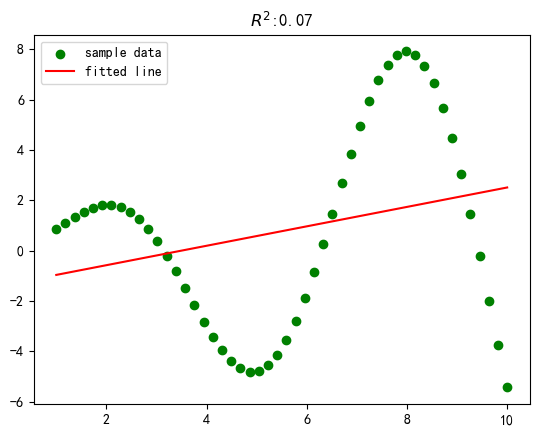

In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
x=np.linspace(1,10,50)
X=x[:,np.newaxis]
print(X.shape)
y=x*np.sin(x)#under fitting
lr=LinearRegression()
lr.fit(X,y)
plt.scatter(X,y,c='g',label='sample data')
plt.plot(X,lr.predict(X),'r-',label='fitted line')
plt.legend()
plt.title(f'$R^2$:{lr.score(X,y):.2f}')

In [2]:
#多项式扩展
from sklearn.preprocessing import PolynomialFeatures
X=np.array([[1,2],[3,4]])
poly=PolynomialFeatures(degree=2)
poly.fit(X)
poly.powers_
X_trans=poly.transform(X)
X_trans

array([[ 1.,  1.,  2.,  1.,  2.,  4.],
       [ 1.,  3.,  4.,  9., 12., 16.]])

In [3]:
from sklearn.preprocessing import PolynomialFeatures

X = np.array([[1, 2], [3, 4]])
print(X)
# degree：扩展阶数。
# include_bias：是否包含偏置项（指数值都为0的项），默认值为True。
poly = PolynomialFeatures(degree=2, include_bias=False)
# 拟合数据，根据训练集X与扩展阶数（degree），就可以确定powers_属性。
poly.fit(X)
print(poly.powers_)
# 将参数X进行多项式转换，返回转换结果。
X_trans = poly.transform(X)
print(X_trans)

# 数据预处理类（例如PolynomialFeatures）的实现：
# fit方法通过训练集用来学习转换规则，转换规则通过属性来进行体现，即将转换规则保存在当前对象的某个属性中。
# 例如例如PolynomialFeatures，转换规则保存在powers_属性中。
# transform方法，通过fit方法学习到的转换规则（属性），就可以对任意的数据进行转换。

X2 = np.array([[10, 2], [2, 9,], [-3, 6]])
print(poly.transform(X2))

# 数据预处理类还具有一个fit_transform的方法。相当于同时调用fit与transform。
# 即：
# poly.fit(X)
# X_trans = poly.transform(X)
# 相当于执行：
# X_trans = poly.fit_transform(X)

# 输入特征的数量，与powers_属性的列数一致。
print(poly.n_features_in_)
# 输出特征的数量，与powers_属性的函数一致。
print(poly.n_output_features_)

# 自行计算转换结果。
for x1, x2 in X:
    for e1, e2 in poly.powers_:
        print(x1 ** e1 * x2 ** e2, end="\t")
    print()

[[1 2]
 [3 4]]
[[1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]
[[ 1.  2.  1.  2.  4.]
 [ 3.  4.  9. 12. 16.]]
[[ 10.   2. 100.  20.   4.]
 [  2.   9.   4.  18.  81.]
 [ -3.   6.   9. -18.  36.]]
2
5
1	2	1	2	4	
3	4	9	12	16	


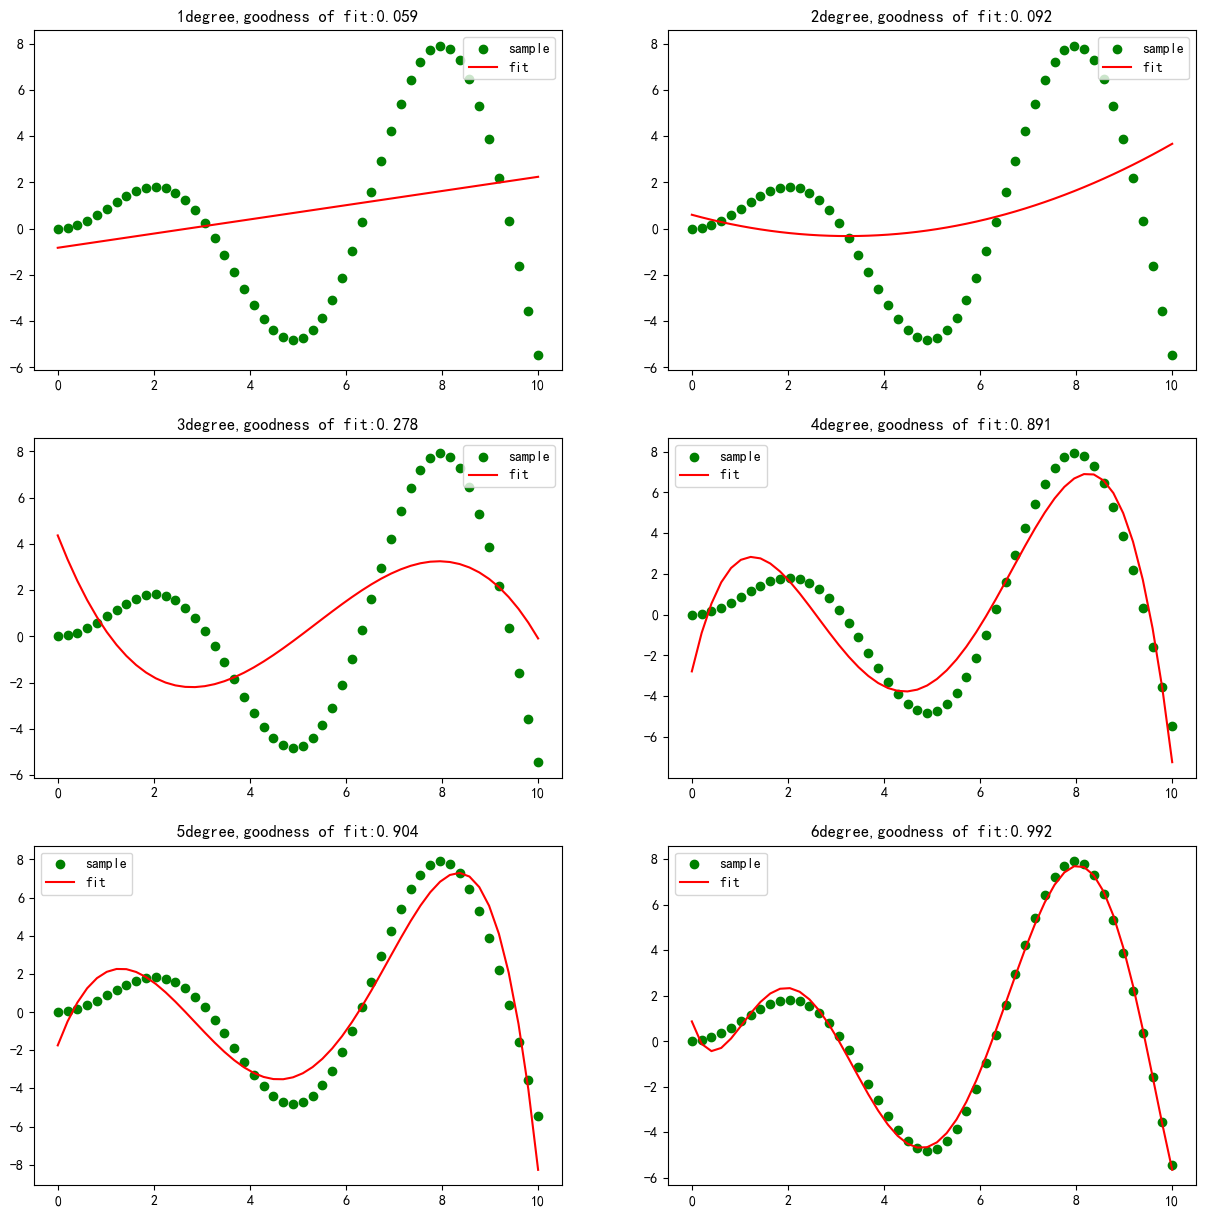

In [4]:
x = np.linspace(0, 10, 50)
y= x * np. sin(x)
X = x[:, np.newaxis]
fig, ax = plt.subplots(3, 2, figsize=(15, 15))
ax = ax.ravel()
for n in range(1, 7):
    poly = PolynomialFeatures(degree=n, include_bias=False)
    X_trans=poly.fit_transform(X)
    lr = LinearRegression()
    lr.fit(X_trans,y)
    ax[n-1].set_title(f'{n}degree,goodness of fit:{lr.score(X_trans,y):.3f}')
    ax[n-1].scatter(X,y,c='g',label='sample')
    ax[n-1].plot(X, lr.predict(X_trans), 'r-', label='fit')
    ax[n-1].legend()
plt.show()

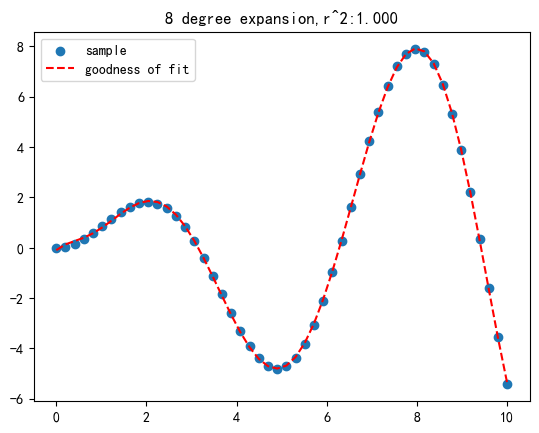

In [5]:
#pipeline
from sklearn.pipeline import Pipeline 
x=np.linspace(0,10,50)
y=x*np.sin(x)
X=x[:,np.newaxis]
step=[('poly',PolynomialFeatures(include_bias=False)),('lr',LinearRegression())]
pipe=Pipeline(steps=step)
pipe.set_params(poly__degree=8)
pipe.fit(X,y)
score=pipe.score(X,y)
plt.title(f'8 degree expansion,r^2:{score:.3f}')
plt.scatter(X,y,label="sample")
plt.plot(X,pipe.predict(X),'r--',label='goodness of fit')
plt.legend()

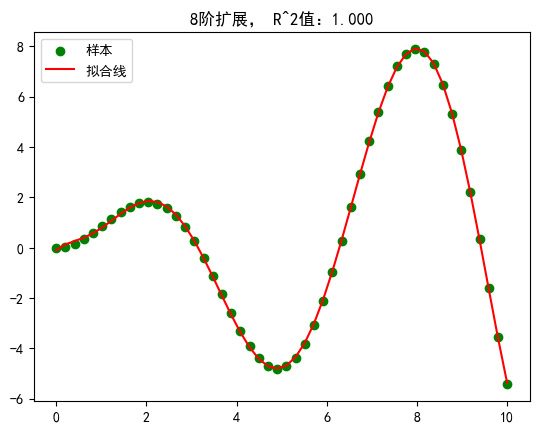

In [6]:
from sklearn.pipeline import Pipeline

x = np.linspace(0, 10, 50)
y = x * np.sin(x)
X = x[:, np.newaxis]
# steps：设置流水线中，数据预处理的步骤。
# 格式：一个含有元组的列表，每个元组包含两个元素，格式：(步骤名, 步骤实现类对象)，每个元组代表一个步骤。
steps = [("poly", PolynomialFeatures(include_bias=False)), ("lr", LinearRegression())]
pipe = Pipeline(steps=steps)
# 我们可以通过流水线对象，来设置其内部步骤实现类对象的参数。
# 语法： 步骤名__参数名
pipe.set_params(poly__degree=8)
# 流水线对象用来代理最后一个评估器，因此，流水线具有最后一个评估器所有的方法。
pipe.fit(X, y)
score = pipe.score(X, y)
plt.title(f"8阶扩展， R^2值：{score:.3f}")
plt.scatter(X, y, c="g", label="样本")
plt.plot(X, pipe.predict(X), c="r", label="拟合线")
plt.legend()

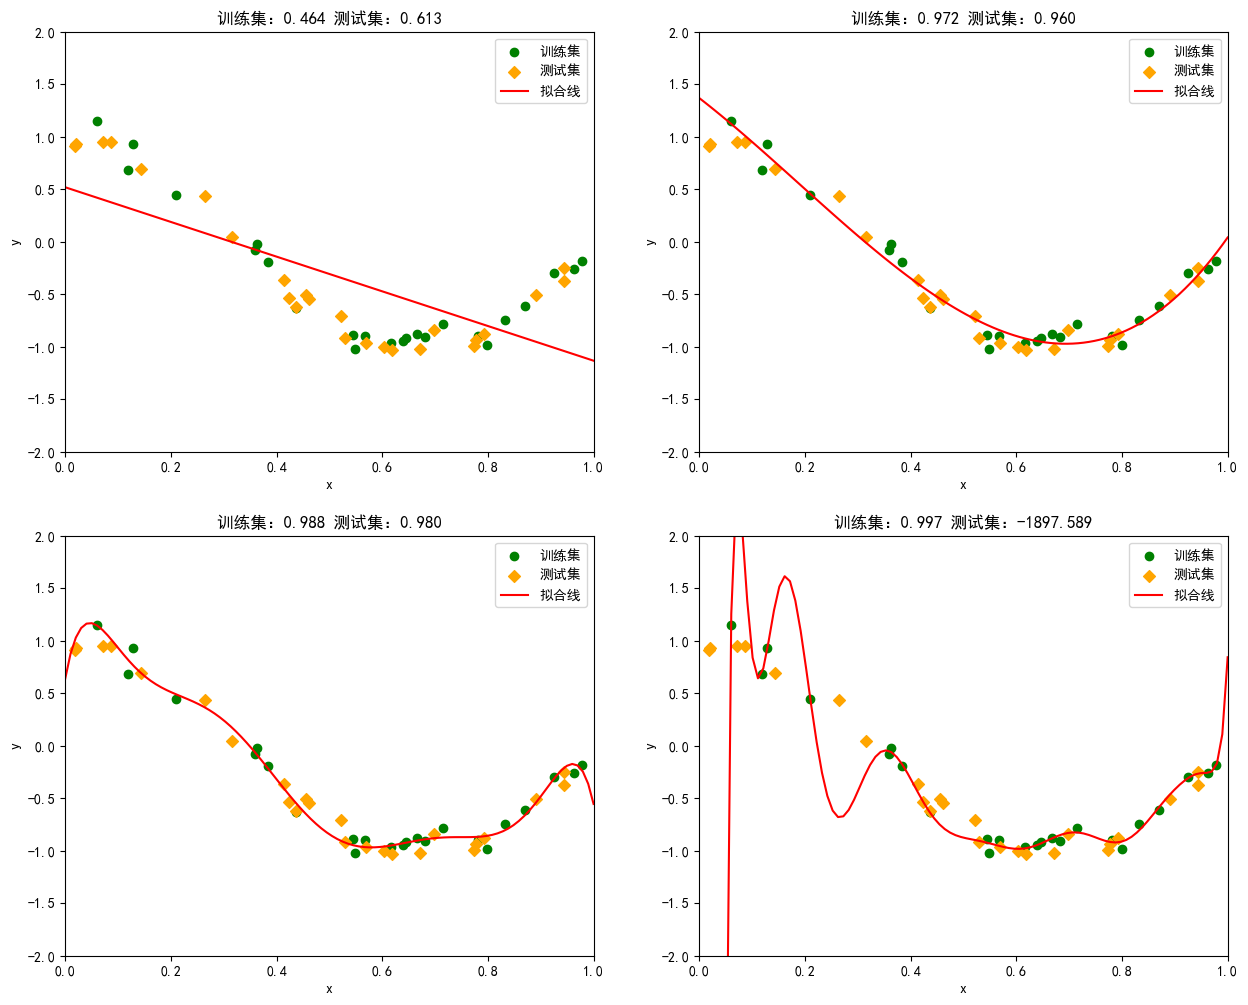

In [7]:
from sklearn.model_selection import train_test_split

def true_fun(x):
    return np.cos(1.5 * np.pi * x)

def fit_and_plot(model):
    np.random.seed(0)
    x = np.random.rand(50)
    y = true_fun(x) + np.random.randn(x.shape[0]) * 0.1
    X = x[:, np.newaxis]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=0)
    model.fit(X_train, y_train)
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    plt.scatter(X_train, y_train, c="g", label="训练集", marker="o")
    plt.scatter(X_test, y_test, c="orange", label="测试集", marker="D")
    s = np.linspace(0, 1, 100).reshape(-1, 1)
    plt.plot(s, model.predict(s), c="r", label="拟合线")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 1)
    plt.ylim(-2, 2)
    plt.legend()
    plt.title(f"训练集：{train_score:.3f} 测试集：{test_score:.3f}")
    
# 定义不同的扩展阶数。
degrees = [1, 3, 8, 15]
plt.figure(figsize=(15, 12))
for i, n in enumerate(degrees):
    plt.subplot(2, 2, i + 1)
    pipe = Pipeline([("poly", PolynomialFeatures(degree=n, include_bias=False)),
                    ("lr", LinearRegression())])
    fit_and_plot(pipe)

Text(0, 0.5, 'weights')

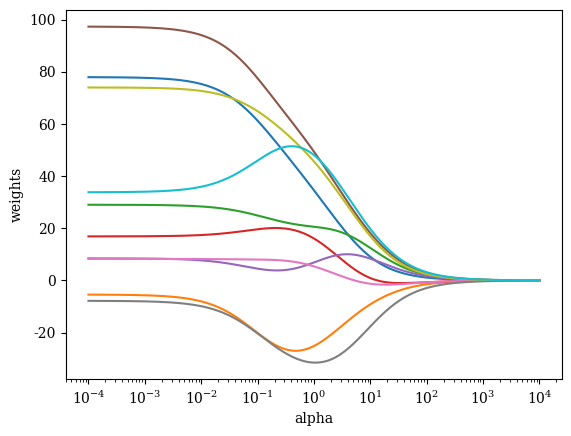

In [8]:
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge

plt.rcParams["font.family"] = "serif"

X, y, w = make_regression(n_samples=10, n_features=10, coef=True, random_state=1, bias=3.5, noise=0)
# 设定超参数alpha。
# 生成对数空间等间隔的数据（对数空间的等差数列，即等比数列）。
# 在base^start ~ base^stop之间，生成num个数据，服从等比数列。
alphas = np.logspace(-4, 4, 200, base=10)
# 定义列表，用来存储在不同的alpha值下，模型拟合出来的权重值。
coefs = []
ridge = Ridge()
for alpha in alphas:
    ridge.set_params(alpha=alpha)
    a=ridge.fit(X, y)
    coefs.append(ridge.coef_)
# 获取当前的绘图区域对象，如果没有对象，则会新创建对象。
ax = plt.gca()
# 当x为一维数组，y为二维数组时，会使用x与y的每一列（一维数组）来绘制一条曲线。
# 在这里，我们绘制的就是每个权重w在200个不同的alpha（惩罚系数）下，拟合出的权重结果。
ax.plot(alphas, coefs)
ax.set_xscale("log")
ax.set_xlabel("alpha")
ax.set_ylabel("weights")

